# Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE

In [1]:
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig

conf1 = GenerationConfig()
conf1.distribution.algorithm = 'clustered'
komorka1 = ImageGenerator(conf1)

conf = GenerationConfig()
conf.axes.mean_x = 22
conf.axes.mean_y = 16
conf.axes.std_x = 6

conf.distribution.algorithm = 'clustered'

komorka2 = ImageGenerator(conf)


set1_tre = komorka1.build_batch(5000)
set1_val = komorka1.build_batch(1000)
set1_test_normal = komorka1.build_batch(2000)

set2_test_large = komorka2.build_batch(2000)

Generated 12 centers
Generated 12 centers
Generated 11 centers
Generated 7 centers
Generated 6 centers
Generated 13 centers
Generated 7 centers
Generated 11 centers
Generated 7 centers
Generated 11 centers
Generated 11 centers
Generated 9 centers
Generated 8 centers
Generated 14 centers
Generated 6 centers
Generated 10 centers
Generated 15 centers
Generated 14 centers
Generated 7 centers
Generated 8 centers
Generated 7 centers
Generated 11 centers
Generated 8 centers
Generated 12 centers
Generated 9 centers
Generated 10 centers
Generated 4 centers
Generated 12 centers
Generated 11 centers
Generated 10 centers
Generated 11 centers
Generated 6 centers
Generated 11 centers
Generated 16 centers
Generated 10 centers
Generated 11 centers
Generated 13 centers
Generated 10 centers
Generated 9 centers
Generated 12 centers
Generated 11 centers
Generated 8 centers
Generated 5 centers
Generated 7 centers
Generated 16 centers
Generated 14 centers
Generated 10 centers
Generated 9 centers
Generated 1

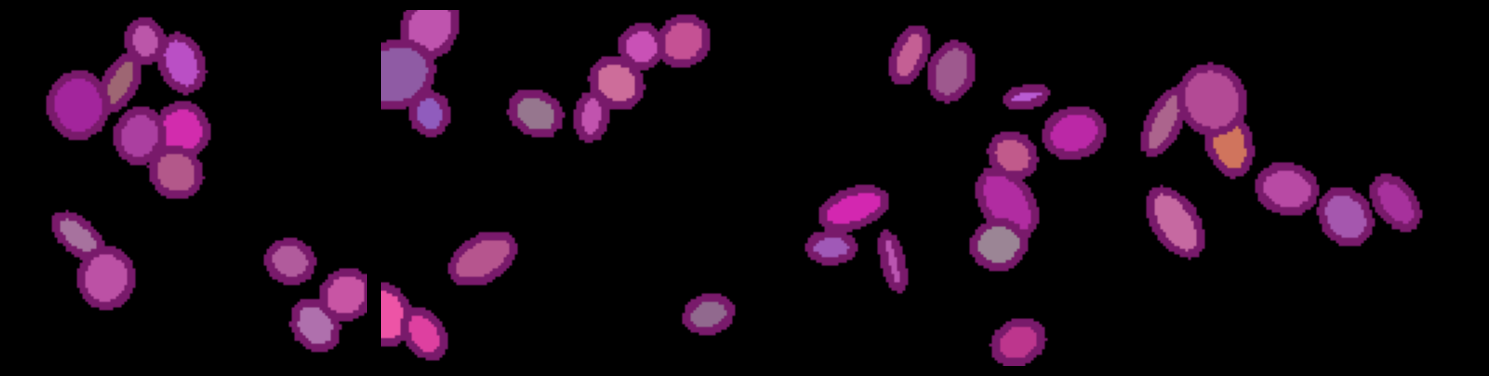

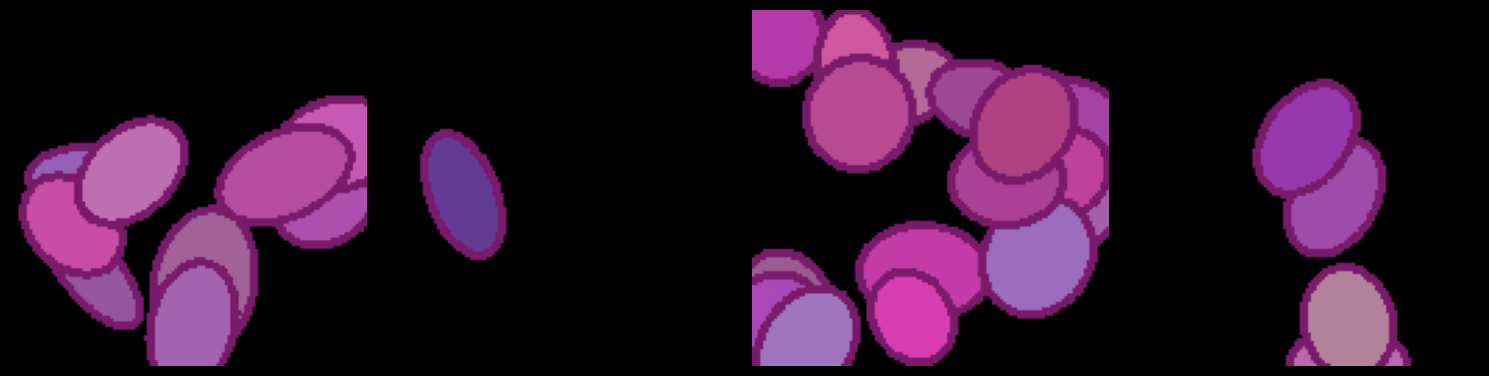

In [2]:
from src.visualization.visualize_output import show_images

show_images(set1_tre[:4])
show_images(set2_test_large[:4])

In [3]:
import numpy as np


def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

x_train = preprocess(set1_tre)
x_val = preprocess(set1_val)
x_test_normal = preprocess(set1_test_normal)
x_test_large = preprocess(set2_test_large)

C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.7889 - loss: 0.1470 - mse: 0.0118 - val_accuracy: 0.8533 - val_loss: 0.1156 - val_mse: 0.0026
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.5549 - loss: 0.1141 - mse: 0.0023 - val_accuracy: 0.2213 - val_loss: 0.1132 - val_mse: 0.0020
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.4593 - loss: 0.1125 - mse: 0.0018 - val_accuracy: 0.5405 - val_loss: 0.1122 - val_mse: 0.0017
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.5429 - loss: 0.1117 - mse: 0.0016 - val_accuracy: 0.5768 - val_loss: 0.1115 - val_mse: 0.0014
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.5837 - loss: 0.1111 - mse: 0.0014 - val_accuracy: 0.5666 - val_loss: 0.1120 - val_mse: 0.0015
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.6105 - loss: 0.1108 - mse: 0.0013 - val_accuracy: 0.6306 - val_loss: 0.1114 - val_mse: 0.0014
Epoch 7/50
157/157 ━━━

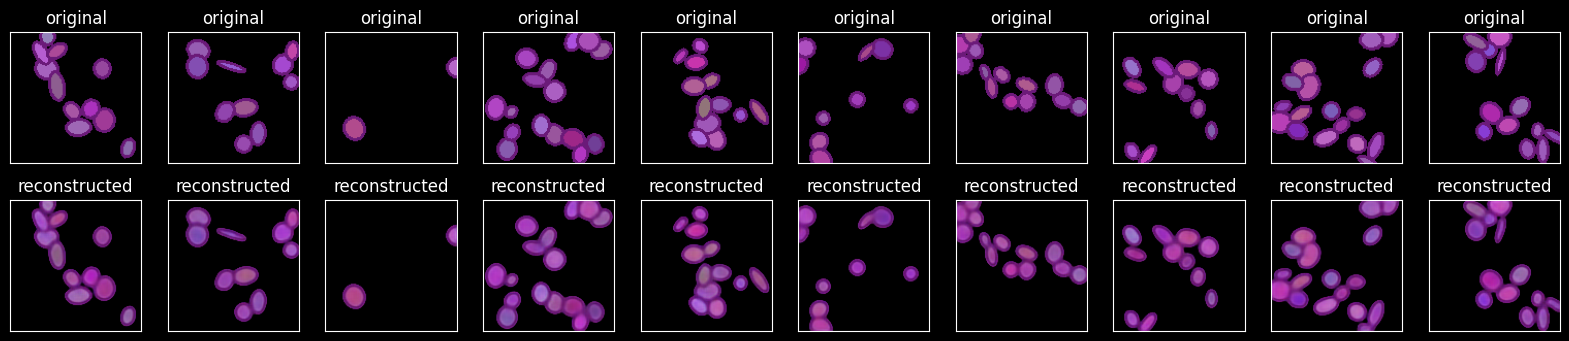


WYNIKI DLA KOMÓREK DUŻYCH


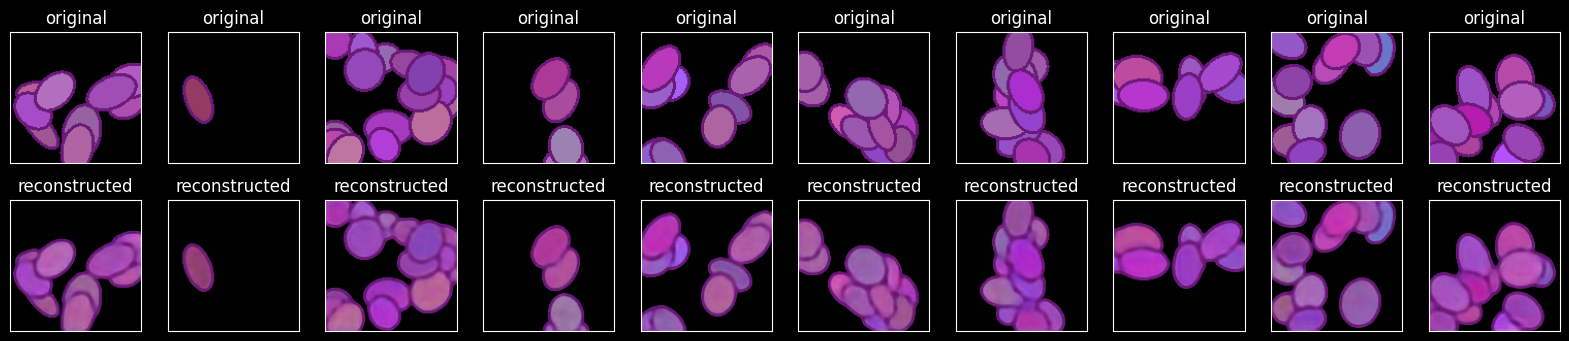

In [4]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_train, x_train,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val, x_val),
    verbose=1
)
decoded_normal = enkoder.predict(x_test_normal)
decoded_large = enkoder.predict(x_test_large)

mse_normal = enkoder.evaluate(x_test_normal, x_test_normal, verbose=0)[0]
mse_large = enkoder.evaluate(x_test_large, x_test_large, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE Large:  {mse_large:.6f}")

print("\n WYNIKI DLA KOMÓREK NORMALNYCH ")
visualize_output(x_test_normal, decoded_normal, 10)

print("\nWYNIKI DLA KOMÓREK DUŻYCH")
visualize_output(x_test_large, decoded_large, 10)